# AWS Comprehend Sentiment Analysis

In [1]:
import pandas as pd
import boto3
import time
import matplotlib.pyplot as plt

print("🧠 Initializing AWS Comprehend client...")

comprehend = boto3.client(
    "comprehend",
    region_name="eu-west-1"
)

print("✅ AWS Comprehend client ready")


🧠 Initializing AWS Comprehend client...
✅ AWS Comprehend client ready


#### Load translated dataset

In [2]:
print("📄 Loading translated articles...")

df = pd.read_csv("articles_final.csv")

print("✅ Dataset loaded")
print("Columns:", list(df.columns))
print("Total rows:", len(df))


📄 Loading translated articles...
✅ Dataset loaded
Columns: ['Source', 'Title', 'URL', 'Language', 'og_text', 'translated_text', 'sentiment', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_mixed']
Total rows: 30


#### Sentiment Columns

In [3]:
sentiment_cols = [
    "sentiment",
    "sentiment_positive",
    "sentiment_negative",
    "sentiment_neutral",
    "sentiment_mixed"
]

for col in sentiment_cols:
    if col not in df.columns:
        df[col] = pd.NA


In [4]:
import time

print("🔍 Running sentiment analysis with AWS Comprehend...")

for idx, row in df[df["translated_text"].notna()].iterrows():
    try:
        full_text = str(row["translated_text"])
        
        # AWS Comprehend limit is 5,000 bytes. 
        # Using 4900 as a safety margin.
        chunk_limit = 4900 
        
        # Split text into chunks
        chunks = [full_text[i:i + chunk_limit] for i in range(0, len(full_text), chunk_limit)]
        
        chunk_responses = []

        for chunk in chunks:
            if chunk.strip():
                resp = comprehend.detect_sentiment(
                    Text=chunk,
                    LanguageCode="en"
                )
                chunk_responses.append(resp)
        
        if not chunk_responses:
            continue

        # Average the Sentiment Scores
        pos = sum(r["SentimentScore"]["Positive"] for r in chunk_responses) / len(chunk_responses)
        neg = sum(r["SentimentScore"]["Negative"] for r in chunk_responses) / len(chunk_responses)
        neu = sum(r["SentimentScore"]["Neutral"] for r in chunk_responses) / len(chunk_responses)
        mix = sum(r["SentimentScore"]["Mixed"] for r in chunk_responses) / len(chunk_responses)

        # Determine the final Sentiment label based on the highest average score
        scores = {"POSITIVE": pos, "NEGATIVE": neg, "NEUTRAL": neu, "MIXED": mix}
        final_sentiment = max(scores, key=scores.get)

        # Save to DataFrame
        df.at[idx, "sentiment"] = final_sentiment
        df.at[idx, "sentiment_positive"] = pos
        df.at[idx, "sentiment_negative"] = neg
        df.at[idx, "sentiment_neutral"] = neu
        df.at[idx, "sentiment_mixed"] = mix

        print(f"✅ Analyzed row {idx} ({len(chunk_responses)} chunks)")
        
        # Small sleep to respect AWS throttling limits
        time.sleep(0.3)

    except Exception as e:
        print(f"❌ Sentiment failed at row {idx}: {str(e)}")

🔍 Running sentiment analysis with AWS Comprehend...
✅ Analyzed row 0 (2 chunks)
✅ Analyzed row 1 (1 chunks)
✅ Analyzed row 2 (4 chunks)
✅ Analyzed row 3 (2 chunks)
✅ Analyzed row 4 (1 chunks)
✅ Analyzed row 5 (2 chunks)
✅ Analyzed row 6 (2 chunks)
✅ Analyzed row 7 (2 chunks)
✅ Analyzed row 8 (1 chunks)
✅ Analyzed row 9 (1 chunks)
✅ Analyzed row 10 (2 chunks)
✅ Analyzed row 11 (1 chunks)
✅ Analyzed row 12 (1 chunks)
✅ Analyzed row 13 (2 chunks)
✅ Analyzed row 14 (2 chunks)
✅ Analyzed row 15 (2 chunks)
✅ Analyzed row 16 (1 chunks)
✅ Analyzed row 17 (2 chunks)
✅ Analyzed row 18 (2 chunks)
✅ Analyzed row 19 (2 chunks)
✅ Analyzed row 20 (2 chunks)
✅ Analyzed row 21 (1 chunks)
✅ Analyzed row 22 (1 chunks)
✅ Analyzed row 23 (1 chunks)
✅ Analyzed row 24 (1 chunks)
✅ Analyzed row 25 (1 chunks)
✅ Analyzed row 26 (1 chunks)
✅ Analyzed row 27 (3 chunks)
✅ Analyzed row 28 (2 chunks)
✅ Analyzed row 29 (2 chunks)


In [5]:
df.to_csv("articles_final.csv", index=False)

print("💾 Sentiment results saved")


💾 Sentiment results saved


### Table 1 — Sentiment distribution

In [9]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts_df = sentiment_counts.reset_index()
sentiment_counts_df.columns = ["Sentiment", "Number of Articles"]

sentiment_counts_df.to_csv(
    "table1_overall_sentiment_distribution.csv",
    index=False
)

sentiment_counts



sentiment
NEUTRAL    28
MIXED       2
Name: count, dtype: int64

### Chart 1 — Overall sentiment distribution

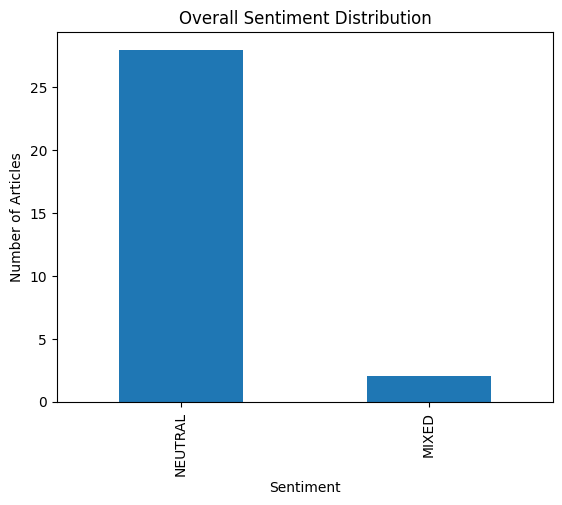

In [10]:
sentiment_counts.plot(kind="bar")
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")

plt.savefig(
    "overall_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




### Table 2 — Sentiment by source

In [15]:
sentiment_by_source = (
    df.groupby(["Source", "sentiment"])
      .size()
      .unstack(fill_value=0)
)

sentiment_by_source.to_csv(
    "table2_sentiment_by_source.csv"
)


sentiment_by_source


sentiment,MIXED,NEUTRAL
Source,,
Prothom Alo,0,10
The Daily Star,2,8
প্রথম আলো,0,10


### Chart 2 — Sentiment comparison by source

/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2469 (\N{BENGALI LETTER THA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/3320050108.py:7: UserWarning: Glyph 2482 (\N

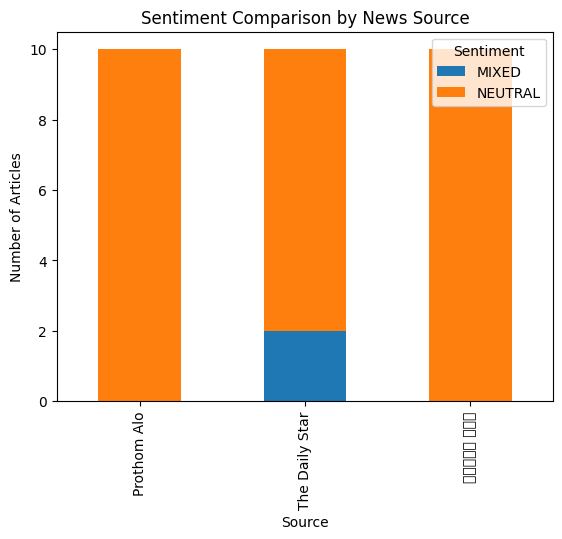

In [16]:
sentiment_by_source.plot(kind="bar", stacked=True)
plt.title("Sentiment Comparison by News Source")
plt.xlabel("Source")
plt.ylabel("Number of Articles")
plt.legend(title="Sentiment")

plt.savefig(
    "Sentiment_By_Source.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Chart 3 — Average sentiment scores by source

/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2469 (\N{BENGALI LETTER THA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_31312/2523337710.py:10: UserWarning: Glyph 

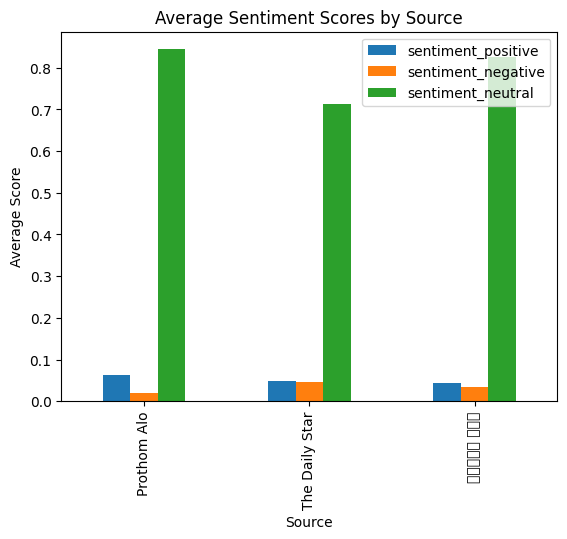

In [17]:
avg_scores = df.groupby("Source")[
    ["sentiment_positive", "sentiment_negative", "sentiment_neutral"]
].mean()

avg_scores.plot(kind="bar")
plt.title("Average Sentiment Scores by Source")
plt.xlabel("Source")
plt.ylabel("Average Score")

plt.savefig(
    "average_sentiment_scores_by_source.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

